In [1]:
import numpy as np
import matplotlib.pyplot as plt


import sys, os
sys.path.append(os.path.abspath("../src"))

from bond import price_coupon_bond, duration_coupon_bond, convexity_coupon_bond, dv01


Text(0.5, 1.0, 'Bond Price vs Yield')

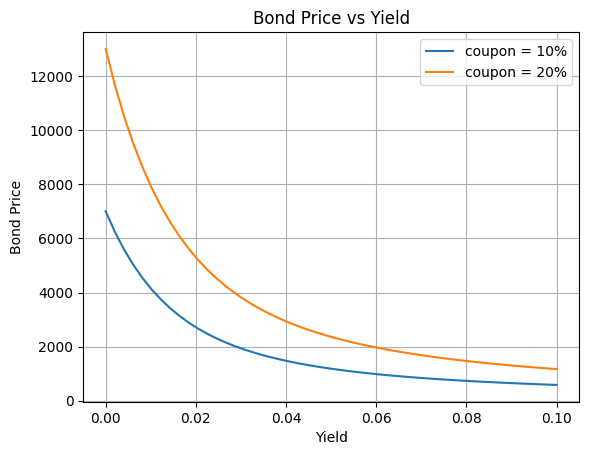

In [2]:
r_grid = np.linspace(0.0, 0.1, 50)
face_value = 1000
coupon_rate = 0.03
periods = 200 
dt = 0.5 
compounding = 'continuous'
prices1 = [price_coupon_bond(face_value, coupon_rate, periods, r, dt, compounding) for r in r_grid]
prices2 = [price_coupon_bond(face_value, coupon_rate*2, periods, r, dt, compounding) for r in r_grid]


plt.plot(r_grid, prices1, label='coupon = 10%')
plt.plot(r_grid, prices2, label='coupon = 20%')
plt.xlabel("Yield")
plt.ylabel("Bond Price")
plt.legend()
plt.grid()
plt.title("Bond Price vs Yield")

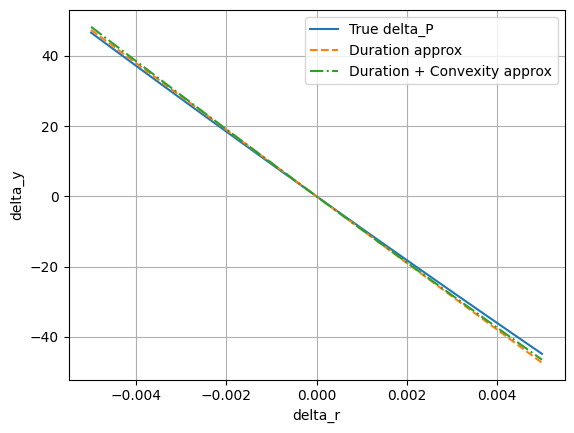

In [3]:
delta_r = np.linspace(-0.005, 0.005, 100)

r = 0.10
face_value = 1000
coupon_rate = 0.10
periods = 20
dt = 0.5
compounding = 'continuous'
prices1 = [price_coupon_bond(face_value, coupon_rate, periods, r, dt, compounding) for r in r_grid]
prices2 = [price_coupon_bond(face_value, coupon_rate*2, periods, r, dt, compounding) for r in r_grid]

price0 = price_coupon_bond(face_value, coupon_rate, periods, r, dt, compounding)
true = [price_coupon_bond(face_value, coupon_rate, periods, r+dr, dt, compounding) - price0 for dr in delta_r]

duration = duration_coupon_bond(face_value, coupon_rate, periods, r, dt, compounding)
duration = duration / (1+r) # modified duration
approx1 = [-duration * price0 * dr for dr in delta_r]

convexity = convexity_coupon_bond(face_value, coupon_rate, periods, r, dt, delta_r=1e-4, compounding=compounding)
approx2 = [-duration * price0 * dr + 0.5 * convexity * price0 * dr**2 for dr in delta_r]

plt.plot(delta_r, true, label="True delta_P")
plt.plot(delta_r, approx1, "--", label="Duration approx")
plt.plot(delta_r, approx2, "-.", label="Duration + Convexity approx")

plt.xlabel('delta_r')
plt.ylabel('delta_y')
plt.legend()
plt.grid()
plt.show()

Text(0.5, 1.0, 'Duration vs Yield')

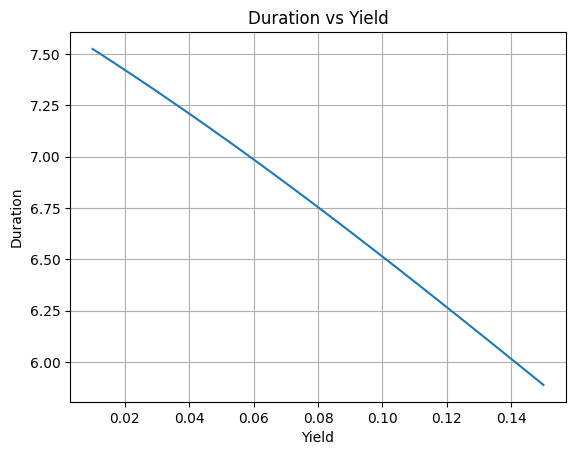

In [4]:
r_grid = np.linspace(0.01, 0.15, 100)

durations = [
    duration_coupon_bond(face_value, coupon_rate, periods, r, dt, compounding)
    for r in r_grid
]

plt.plot(r_grid, durations)
plt.xlabel("Yield")
plt.ylabel("Duration")
plt.grid()
plt.title("Duration vs Yield")

Text(0.5, 1.0, 'Convexity vs Yield')

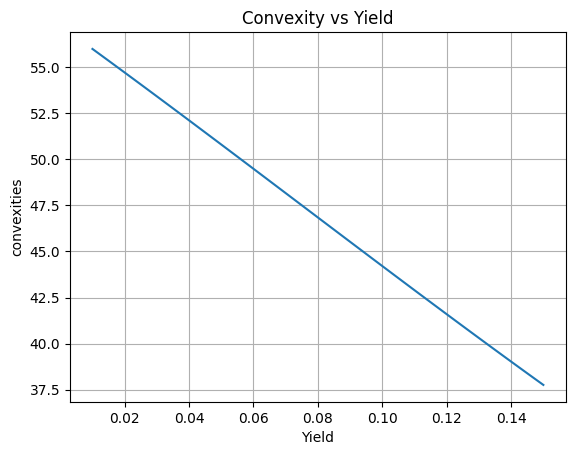

In [5]:
convexities = [
    convexity_coupon_bond(face_value, coupon_rate, periods, r, dt, compounding=compounding)
    for r in r_grid
]
plt.plot(r_grid, convexities)
plt.xlabel("Yield")
plt.ylabel("convexities")
plt.grid()
plt.title("Convexity vs Yield")

Text(0.5, 1.0, 'dv01_values vs Yield')

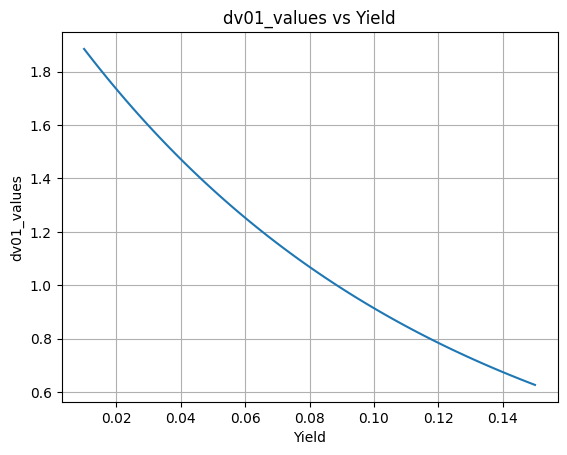

In [6]:
dv01_values = [
    dv01(face_value, coupon_rate, periods, r, dt, compounding=compounding)
    for r in r_grid
]

plt.plot(r_grid, dv01_values)
plt.xlabel("Yield")
plt.ylabel("dv01_values")
plt.grid()
plt.title("dv01_values vs Yield")

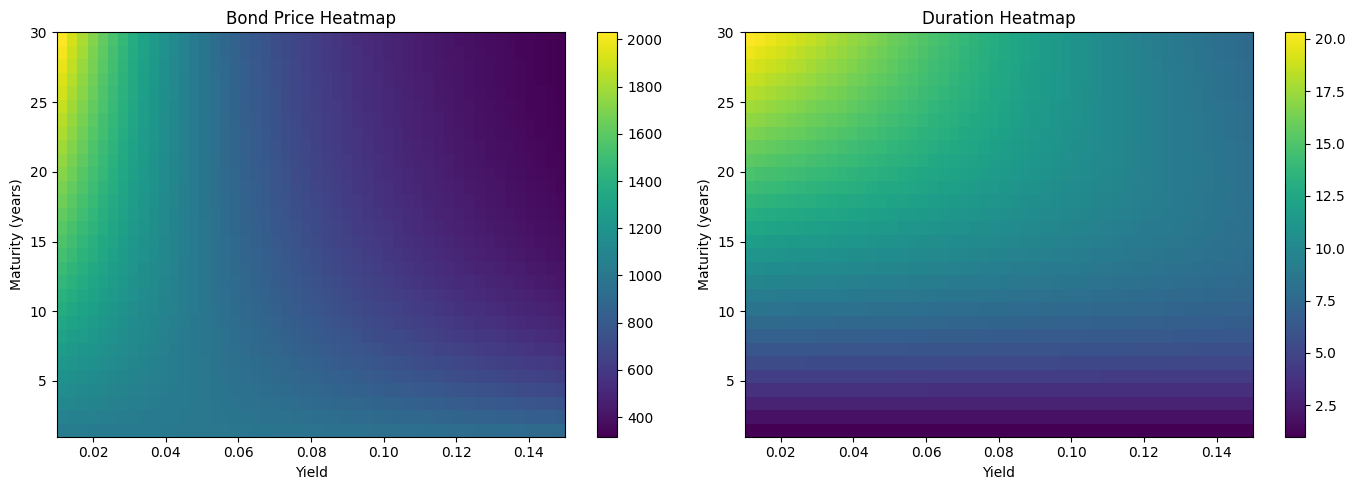

In [7]:
# Parameters
face_value = 1000
coupon_rate = 0.05
dt = 1
compounding = "continuous"

# Grid
yield_grid = np.linspace(0.01, 0.15, 50)     # x-axis
maturity_grid = np.arange(1, 31)              # y-axis

price_matrix = np.zeros((len(maturity_grid), len(yield_grid)))
duration_matrix = np.zeros((len(maturity_grid), len(yield_grid)))

for i, T in enumerate(maturity_grid):
    periods = int(T / dt)
    
    for j, r in enumerate(yield_grid):
        # Price
        price_matrix[i, j] = price_coupon_bond(
            face_value, coupon_rate, periods, r, dt, compounding
        )
        
        # Duration
        duration_matrix[i, j] = duration_coupon_bond(
            face_value, coupon_rate, periods, r, dt, compounding
        )

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# price heatmap
im1 = axes[0].imshow(
    price_matrix,
    aspect='auto',
    origin='lower',
    extent=[yield_grid.min(), yield_grid.max(),
            maturity_grid.min(), maturity_grid.max()]
)
axes[0].set_title("Bond Price Heatmap")
axes[0].set_xlabel("Yield")
axes[0].set_ylabel("Maturity (years)")
fig.colorbar(im1, ax=axes[0])

# duration heatmap
im2 = axes[1].imshow(
    duration_matrix,
    aspect='auto',
    origin='lower',
    extent=[yield_grid.min(), yield_grid.max(),
            maturity_grid.min(), maturity_grid.max()]
)
axes[1].set_title("Duration Heatmap")
axes[1].set_xlabel("Yield")
axes[1].set_ylabel("Maturity (years)")
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()